# Load required libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataframe

In [42]:
df = pd.read_csv("data_small/TG_STAID000001.txt", skiprows=20, parse_dates=["    DATE"])

In [43]:
df

,STAID,SOUID,DATE,TG,Q_TG
0,1,35381,1860-01-01,21,0
1,1,35381,1860-01-02,46,0
2,1,35381,1860-01-03,31,0
3,1,35381,1860-01-04,37,0
4,1,35381,1860-01-05,31,0
...,...,...,...,...,...
59316,1,35381,2022-05-27,-9999,9
59317,1,35381,2022-05-28,-9999,9
59318,1,35381,2022-05-29,-9999,9
59319,1,35381,2022-05-30,-9999,9


# Show certain rows

In [44]:
df[10:20]

,STAID,SOUID,DATE,TG,Q_TG
10,1,35381,1860-01-11,-5,0
11,1,35381,1860-01-12,-18,0
12,1,35381,1860-01-13,-27,0
13,1,35381,1860-01-14,-26,0
14,1,35381,1860-01-15,-37,0
15,1,35381,1860-01-16,-9,0
16,1,35381,1860-01-17,7,0
17,1,35381,1860-01-18,-6,0
18,1,35381,1860-01-19,-16,0
19,1,35381,1860-01-20,-19,0


# Show certain columns

In [45]:
df.columns

Index(['STAID', ' SOUID', '    DATE', '   TG', ' Q_TG'], dtype='object')

In [46]:
df[['   TG', ' Q_TG']]

,TG,Q_TG
0,21,0
1,46,0
2,31,0
3,37,0
4,31,0
...,...,...
59316,-9999,9
59317,-9999,9
59318,-9999,9
59319,-9999,9


# General Info

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59321 entries, 0 to 59320
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   STAID     59321 non-null  int64         
 1    SOUID    59321 non-null  int64         
 2       DATE  59321 non-null  datetime64[ns]
 3      TG     59321 non-null  int64         
 4    Q_TG     59321 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 2.3 MB


# Filtering

In [48]:
df.loc[df['   TG']==-9999]

,STAID,SOUID,DATE,TG,Q_TG
45,1,35381,1860-02-15,-9999,9
70,1,35381,1860-03-11,-9999,9
251,1,35381,1860-09-08,-9999,9
525,1,35381,1861-06-09,-9999,9
539,1,35381,1861-06-23,-9999,9
...,...,...,...,...,...
59316,1,35381,2022-05-27,-9999,9
59317,1,35381,2022-05-28,-9999,9
59318,1,35381,2022-05-29,-9999,9
59319,1,35381,2022-05-30,-9999,9


In [49]:
df["TG0"] = df['   TG'].mask(df['   TG']==-9999, np.nan)

In [50]:
df

,STAID,SOUID,DATE,TG,Q_TG,TG0
0,1,35381,1860-01-01,21,0,21.0
1,1,35381,1860-01-02,46,0,46.0
2,1,35381,1860-01-03,31,0,31.0
3,1,35381,1860-01-04,37,0,37.0
4,1,35381,1860-01-05,31,0,31.0
...,...,...,...,...,...,...
59316,1,35381,2022-05-27,-9999,9,NaN
59317,1,35381,2022-05-28,-9999,9,NaN
59318,1,35381,2022-05-29,-9999,9,NaN
59319,1,35381,2022-05-30,-9999,9,NaN


In [51]:
df['TG'] = df['TG0']/10

In [52]:
df.head()

,STAID,SOUID,DATE,TG,Q_TG,TG0,TG
0,1,35381,1860-01-01,21,0,21.0,2.1
1,1,35381,1860-01-02,46,0,46.0,4.6
2,1,35381,1860-01-03,31,0,31.0,3.1
3,1,35381,1860-01-04,37,0,37.0,3.7
4,1,35381,1860-01-05,31,0,31.0,3.1


In [53]:
df['Fahrenheit'] = df['TG'] * (9/5) +32

In [54]:
df.head()

,STAID,SOUID,DATE,TG,Q_TG,TG0,TG,Fahrenheit
0,1,35381,1860-01-01,21,0,21.0,2.1,35.78
1,1,35381,1860-01-02,46,0,46.0,4.6,40.28
2,1,35381,1860-01-03,31,0,31.0,3.1,37.58
3,1,35381,1860-01-04,37,0,37.0,3.7,38.66
4,1,35381,1860-01-05,31,0,31.0,3.1,37.58


In [55]:
df['TG'].mean()

np.float64(6.360787526128468)

In [56]:
df['TG'].max()

np.float64(26.2)

In [57]:
df['TG'].min()

np.float64(-28.8)

<Axes: >

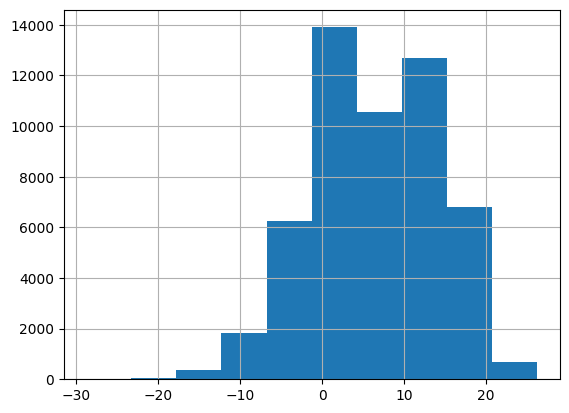

In [58]:
df['TG'].hist()

<Axes: xlabel='    DATE'>

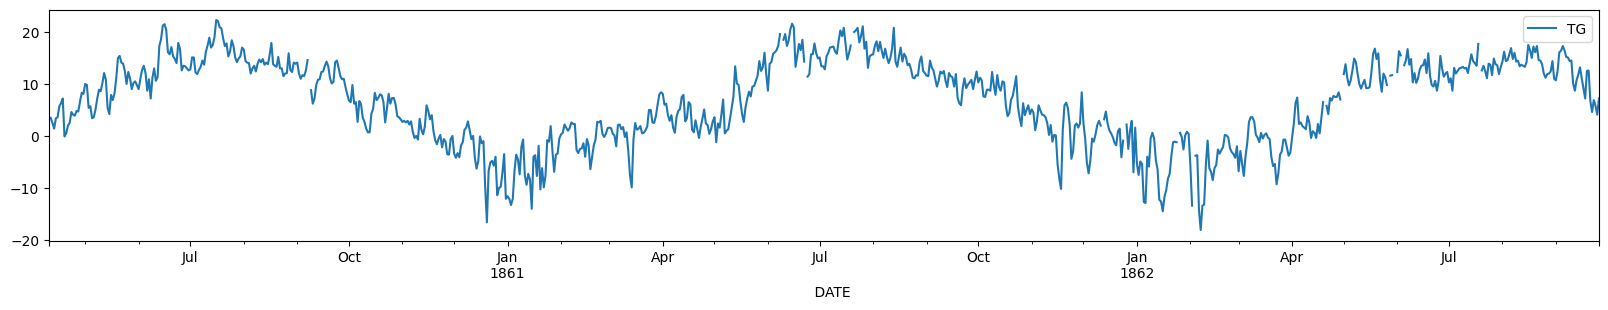

In [63]:
df[100:1000].plot(x='    DATE', y='TG', figsize=(20,3))

# Get certain cells

In [59]:
df.loc[df['    DATE']=='1860-01-14']['TG'].squeeze()

np.float64(-2.6)

In [60]:
df.loc[df['TG']==df['TG'].max()]

,STAID,SOUID,DATE,TG,Q_TG,TG0,TG,Fahrenheit
3150,1,35381,1868-08-16,262,0,262.0,26.2,79.16
